In [17]:
import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.metrics import roc_auc_score

In [18]:
#adata = sc.read('validation/diff_gene/stagei/Lung_Cancer_HD_Only_Experiment1T_cell.h5ad')

In [19]:
adata1 = sc.read('validation/diff_gene/stagei/Lung_Cancer_HD_Only_Experiment1T_cell.h5ad')
adata2 = sc.read('validation/diff_gene/stagei/Breast_Cancer_FreshT_cell.h5ad')
adata3 = sc.read('validation/diff_gene/stagei/Colon_Cancer_P1T_cell.h5ad')
adata4 = sc.read('validation/diff_gene/stagei/Colon_Cancer_P2T_cell.h5ad')
adata5 = sc.read('validation/diff_gene/stagei/Colon_Cancer_P5T_cell.h5ad')
adata6 = sc.read('validation/diff_gene/stagei/HumanLungCancerT_cell.h5ad')
adata7 = sc.read('validation/diff_gene/stagei/Lung_Cancer_Fixed_FrozenT_cell.h5ad')

adatas = [adata1, adata2, adata3, adata4, adata5, adata6, adata7]
adata = sc.concat(adatas, join='inner', axis=0) 

/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [20]:
adata.obs

,in_tissue,array_row,array_col,X,Y,n_genes,tumor_gene_signature,stromal_immune_gene_signature,t_gene_signature,b_gene_signature,...,macrophage_gene_signature,endothelial_gene_signature,fibroblast_gene_signature,leiden,T,B,Endothelial,cell_type,T_pred,T_pred_binary
s_008um_00086_00091-1,1,86,91,728,688,240,3.649441,44.473354,0.000000,0.000000,...,0.000000,0.000000,3.649441,3,1,0,0,2,0.457466,0
s_008um_00123_00164-1,1,123,164,1312,984,288,6.869911,17.174776,0.000000,0.000000,...,0.000000,3.434955,4.111858,1,0,0,0,1,0.633178,1
s_008um_00013_00648-1,1,13,648,5184,104,275,11.581820,24.508215,0.000000,0.000000,...,3.501174,0.000000,0.000000,0,0,0,0,1,0.611822,1
s_008um_00161_00253-1,1,161,253,2024,1288,361,7.095243,32.688744,0.000000,3.211228,...,0.000000,0.000000,3.884016,1,0,0,0,1,0.588026,0
s_008um_00401_00407-1,1,401,407,3256,3208,386,3.168805,31.331490,0.000000,7.407785,...,0.000000,0.000000,0.000000,2,0,0,0,1,0.589960,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00413_00584-1,1,413,584,4672,3304,414,2.996302,125.531693,0.000000,0.000000,...,3.664146,0.000000,16.118343,1,1,0,0,2,0.517139,0
s_008um_00530_00360-1,1,530,360,2880,4240,334,0.000000,121.214699,0.000000,3.335779,...,10.007338,3.335779,12.996872,1,1,0,0,2,0.653001,1
s_008um_00613_00323-1,1,613,323,2584,4904,376,0.000000,100.734245,0.000000,8.400785,...,12.987769,3.079471,14.227851,1,1,0,0,2,0.599757,1
s_008um_00032_00192-1,1,32,192,1536,256,594,5.212338,140.226547,0.000000,0.000000,...,28.990385,2.606169,14.618200,1,1,0,0,2,0.525483,0


In [21]:
roc_auc_score(adata.obs['T'], adata.obs['T_pred'])

0.7684680619120513

In [22]:
roc_auc_score(adata.obs['T'], adata.obs['T_pred_binary'])

0.7108150795959931

In [23]:
# Subset cells where T == 1
subset = adata[adata.obs['T'] == 1]
subset.obs

,in_tissue,array_row,array_col,X,Y,n_genes,tumor_gene_signature,stromal_immune_gene_signature,t_gene_signature,b_gene_signature,...,macrophage_gene_signature,endothelial_gene_signature,fibroblast_gene_signature,leiden,T,B,Endothelial,cell_type,T_pred,T_pred_binary
s_008um_00086_00091-1,1,86,91,728,688,240,3.649441,44.473354,0.000000,0.000000,...,0.000000,0.000000,3.649441,3,1,0,0,2,0.457466,0
s_008um_00117_00728-1,1,117,728,5824,936,328,0.000000,81.777809,0.000000,3.351594,...,7.378666,0.000000,6.703188,3,1,0,0,2,0.640892,1
s_008um_00498_00411-1,1,498,411,3288,3984,273,3.542612,71.530800,0.000000,7.085223,...,3.542612,3.542612,0.000000,3,1,0,0,2,0.643917,1
s_008um_00101_00721-1,1,101,721,5768,808,272,3.526458,80.295410,4.204791,3.526458,...,0.000000,0.000000,7.052915,3,1,0,0,2,0.572316,0
s_008um_00118_00727-1,1,118,727,5816,944,265,0.000000,81.079498,0.000000,3.592800,...,3.592800,0.000000,7.185601,3,1,0,0,2,0.646632,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00413_00584-1,1,413,584,4672,3304,414,2.996302,125.531693,0.000000,0.000000,...,3.664146,0.000000,16.118343,1,1,0,0,2,0.517139,0
s_008um_00530_00360-1,1,530,360,2880,4240,334,0.000000,121.214699,0.000000,3.335779,...,10.007338,3.335779,12.996872,1,1,0,0,2,0.653001,1
s_008um_00613_00323-1,1,613,323,2584,4904,376,0.000000,100.734245,0.000000,8.400785,...,12.987769,3.079471,14.227851,1,1,0,0,2,0.599757,1
s_008um_00032_00192-1,1,32,192,1536,256,594,5.212338,140.226547,0.000000,0.000000,...,28.990385,2.606169,14.618200,1,1,0,0,2,0.525483,0


In [24]:

# Create a new column for grouping
subset.obs['group'] = subset.obs['T_pred_binary'].astype(str)


/tmp/ipykernel_42861/2810431963.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subset.obs['group'] = subset.obs['T_pred_binary'].astype(str)


/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [25]:

# Perform differential gene analysis
sc.tl.rank_genes_groups(subset, groupby='group', reference='0')


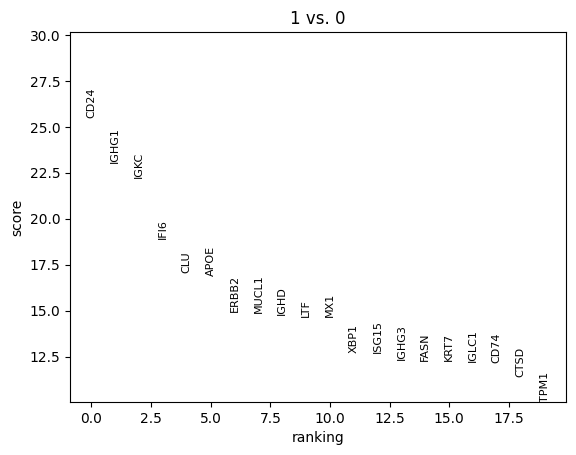

In [26]:

# Visualize the top markers
sc.pl.rank_genes_groups(subset, groups=['1'], reference='0',
                        save='all_data_diff_gene_markers.pdf')

In [27]:
subset

AnnData object with n_obs × n_vars = 48118 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'X', 'Y', 'n_genes', 'tumor_gene_signature', 'stromal_immune_gene_signature', 't_gene_signature', 'b_gene_signature', 'neutrophil_gene_signature', 'macrophage_gene_signature', 'endothelial_gene_signature', 'fibroblast_gene_signature', 'leiden', 'T', 'B', 'Endothelial', 'cell_type', 'T_pred', 'T_pred_binary', 'group'
    uns: 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [28]:
mean_expression = subset.to_df().mean(axis=0)


In [29]:

differential_genes = pd.DataFrame({
    'gene': subset.uns['rank_genes_groups']['names']['1'],
    'logfoldchange': subset.uns['rank_genes_groups']['logfoldchanges']['1'],
    'pvals': subset.uns['rank_genes_groups']['pvals']['1'],
    'adjusted_pvals': subset.uns['rank_genes_groups']['pvals_adj']['1'],
})

In [30]:
differential_genes['average_count_tcell'] = differential_genes['gene'].map(mean_expression)


In [33]:
differential_genes

,gene,logfoldchange,pvals,adjusted_pvals,average_count_tcell
0,CD24,0.889778,7.229687e-142,1.307489e-137,1.541697
1,IGHG1,0.974423,4.684965e-116,4.236380e-112,4.057166
2,IGKC,0.908445,3.003428e-108,1.810567e-104,4.929726
3,IFI6,0.660835,3.255771e-79,1.472016e-75,0.967626
4,CLU,0.621759,6.835458e-65,2.472385e-61,1.043631
...,...,...,...,...,...
18080,SRGN,-0.509655,1.512205e-29,1.139510e-26,0.499979
18081,RGS1,-0.494138,2.414644e-30,1.984947e-27,0.503436
18082,CEACAM6,-0.926735,1.610610e-30,1.387042e-27,0.112950
18083,S100A6,-0.499141,1.623484e-42,2.258516e-39,0.976162


In [34]:
differential_genes

,gene,logfoldchange,pvals,adjusted_pvals,average_count_tcell
0,CD24,0.889778,7.229687e-142,1.307489e-137,1.541697
1,IGHG1,0.974423,4.684965e-116,4.236380e-112,4.057166
2,IGKC,0.908445,3.003428e-108,1.810567e-104,4.929726
3,IFI6,0.660835,3.255771e-79,1.472016e-75,0.967626
4,CLU,0.621759,6.835458e-65,2.472385e-61,1.043631
...,...,...,...,...,...
18080,SRGN,-0.509655,1.512205e-29,1.139510e-26,0.499979
18081,RGS1,-0.494138,2.414644e-30,1.984947e-27,0.503436
18082,CEACAM6,-0.926735,1.610610e-30,1.387042e-27,0.112950
18083,S100A6,-0.499141,1.623484e-42,2.258516e-39,0.976162


In [35]:
differential_genes.to_csv('validation/diff_gene/stagei/results/all_data_diff_gene_markers.csv', index=False)

In [208]:
# %%
import matplotlib.pyplot as plt
import seaborn as sns

# %%
# Add a new column to indicate if the gene is upregulated or downregulated
differential_genes['regulation'] = differential_genes['logfoldchange'].apply(
    lambda x: 'Upregulated' if x > 0 else 'Downregulated'
)

# %%
# Count the number of upregulated and downregulated genes
regulation_counts = differential_genes['regulation'].value_counts()


In [209]:
"""
# Plot the counts
plt.figure(figsize=(6, 4))
sns.barplot(x=regulation_counts.index, y=regulation_counts.values, palette="coolwarm")
plt.title('Number of Upregulated and Downregulated Genes')
plt.ylabel('Number of Genes')
plt.xlabel('Regulation')
plt.tight_layout()
plt.savefig('validation/diff_gene/stagei/figures/all_data/gene_regulation_counts.pdf')
plt.show()
"""

'\n# Plot the counts\nplt.figure(figsize=(6, 4))\nsns.barplot(x=regulation_counts.index, y=regulation_counts.values, palette="coolwarm")\nplt.title(\'Number of Upregulated and Downregulated Genes\')\nplt.ylabel(\'Number of Genes\')\nplt.xlabel(\'Regulation\')\nplt.tight_layout()\nplt.savefig(\'validation/diff_gene/stagei/figures/all_data/gene_regulation_counts.pdf\')\nplt.show()\n'

In [210]:
"""
# %%
# Create a volcano plot for visualization of differential genes
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=differential_genes['logfoldchange'],
    y=-np.log10(differential_genes['adjusted_pvals']),
    hue=differential_genes['regulation'],
    palette={"Upregulated": "red", "Downregulated": "blue"},
    alpha=0.7
)
plt.axhline(-np.log10(0.05), color='gray', linestyle='--', label='Adjusted p-value = 0.05')
plt.axvline(0, color='black', linestyle='--')
plt.title('Volcano Plot of Differentially Expressed Genes')
plt.xlabel('Log Fold Change')
plt.ylabel('-log10(Adjusted p-value)')
plt.legend(title='Regulation')
plt.tight_layout()
plt.savefig('validation/diff_gene/stagei/all_data/volcano_plot.pdf')
plt.show()"""


'\n# %%\n# Create a volcano plot for visualization of differential genes\nplt.figure(figsize=(10, 6))\nsns.scatterplot(\n    x=differential_genes[\'logfoldchange\'],\n    y=-np.log10(differential_genes[\'adjusted_pvals\']),\n    hue=differential_genes[\'regulation\'],\n    palette={"Upregulated": "red", "Downregulated": "blue"},\n    alpha=0.7\n)\nplt.axhline(-np.log10(0.05), color=\'gray\', linestyle=\'--\', label=\'Adjusted p-value = 0.05\')\nplt.axvline(0, color=\'black\', linestyle=\'--\')\nplt.title(\'Volcano Plot of Differentially Expressed Genes\')\nplt.xlabel(\'Log Fold Change\')\nplt.ylabel(\'-log10(Adjusted p-value)\')\nplt.legend(title=\'Regulation\')\nplt.tight_layout()\nplt.savefig(\'validation/diff_gene/stagei/all_data/volcano_plot.pdf\')\nplt.show()'

In [211]:

# %%
# Save the categorized differential genes to a CSV file
differential_genes.to_csv('validation/diff_gene/stagei/figures/all_data_diff_gene_markers_with_regulation.csv', index=False)


In [212]:

top_upregulated = differential_genes[differential_genes['regulation'] == 'Upregulated'].nlargest(20, 'logfoldchange')
top_downregulated = differential_genes[differential_genes['regulation'] == 'Downregulated'].nsmallest(20, 'logfoldchange')

top_genes = pd.concat([top_upregulated, top_downregulated])


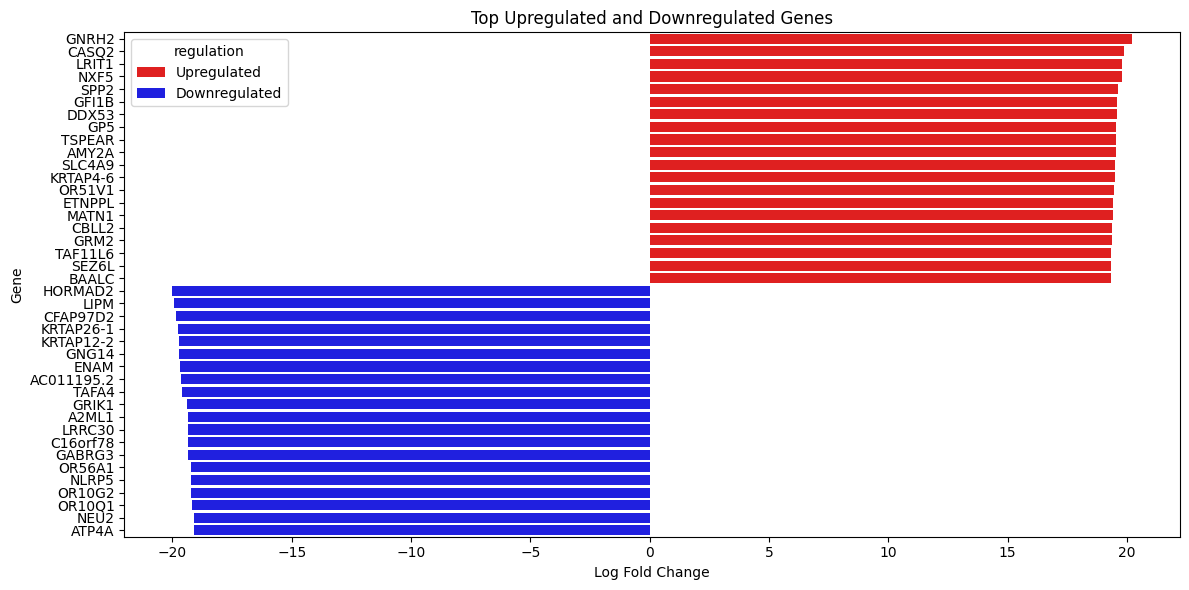

In [213]:

# Plot top genes
plt.figure(figsize=(12, 6))
sns.barplot(
    x='logfoldchange', y='gene', hue='regulation', data=top_genes,
    palette={"Upregulated": "red", "Downregulated": "blue"}
)
plt.title('Top Upregulated and Downregulated Genes')
plt.xlabel('Log Fold Change')
plt.ylabel('Gene')
plt.tight_layout()
plt.savefig('validation/diff_gene/stagei/figures/all_data_top_genes_barplot.pdf')
plt.show()

In [221]:
differential_genes['regulation'] = differential_genes['logfoldchange'].apply(
    lambda x: 'Upregulated' if x > 0 else 'Downregulated'
)
differential_genes

,gene,logfoldchange,pvals,adjusted_pvals,regulation,rank
0,CD24,0.889778,7.229687e-142,1.307489e-137,Upregulated,840.0
1,IGHG1,0.974423,4.684965e-116,4.236380e-112,Upregulated,786.0
2,IGKC,0.908445,3.003428e-108,1.810567e-104,Upregulated,823.0
3,IFI6,0.660835,3.255771e-79,1.472016e-75,Upregulated,1083.0
4,CLU,0.621759,6.835458e-65,2.472385e-61,Upregulated,1147.0
...,...,...,...,...,...,...
18080,SRGN,-0.509655,1.512205e-29,1.139510e-26,Downregulated,9066.0
18081,RGS1,-0.494138,2.414644e-30,1.984947e-27,Downregulated,8991.0
18082,CEACAM6,-0.926735,1.610610e-30,1.387042e-27,Downregulated,10170.0
18083,S100A6,-0.499141,1.623484e-42,2.258516e-39,Downregulated,9015.0


In [222]:
differential_genes['rank'] = differential_genes.groupby('regulation')['logfoldchange'].rank(method='min', ascending=False)


In [223]:
upregulated_genes = differential_genes[differential_genes['regulation'] == 'Upregulated'].copy()
downregulated_genes = differential_genes[differential_genes['regulation'] == 'Downregulated'].copy()


In [224]:
upregulated_genes

,gene,logfoldchange,pvals,adjusted_pvals,regulation,rank
0,CD24,0.889778,7.229687e-142,1.307489e-137,Upregulated,840.0
1,IGHG1,0.974423,4.684965e-116,4.236380e-112,Upregulated,786.0
2,IGKC,0.908445,3.003428e-108,1.810567e-104,Upregulated,823.0
3,IFI6,0.660835,3.255771e-79,1.472016e-75,Upregulated,1083.0
4,CLU,0.621759,6.835458e-65,2.472385e-61,Upregulated,1147.0
...,...,...,...,...,...,...
6697,RNF19B,0.000116,9.984511e-01,1.000000e+00,Upregulated,6701.0
6698,C10orf71,0.002690,9.987136e-01,1.000000e+00,Upregulated,6622.0
6699,EPHX4,0.000601,9.987889e-01,1.000000e+00,Upregulated,6686.0
6700,USP10,0.000079,9.992639e-01,1.000000e+00,Upregulated,6702.0
